In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('kc_house_data.csv')

Seleção de Variáveis (Features e Target)

In [4]:
x_data = df[['sqft_living']].values
y_data = df[['price']].values

Pré-processamento: Padronização dos dados

In [5]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

In [6]:
x_scaled = scaler_x.fit_transform(x_data)
y_scaled = scaler_y.fit_transform(y_data)

Divisão em Treino e Teste (80% para treinar, 20% para validar)

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

# Convertendo os dados do Numpy para Tensores do PyTorch
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

Definição do Modelo PyTorch

In [8]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

In [9]:
model = LinearRegressionModel(1, 1)

Função de Custo (MSE) e Otimizador

In [10]:
criterion = nn.MSELoss()
# Taxa de aprendizado (lr)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Laço de Treinamento

In [11]:
epochs = 1000
train_losses = []

print("Iniciando o Treinamento...")
for epoch in range(epochs):
    # Forward pass: calcular a predição da rede
    y_pred = model(x_train)

    # Cálculo da Perda (Loss)
    loss = criterion(y_pred, y_train)
    train_losses.append(loss.item())

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    if (epoch + 1) % 100 == 0:
        print(f'Época [{epoch+1}/{epochs}], Perda (MSE): {loss.item():.4f}')

Iniciando o Treinamento...
Época [100/1000], Perda (MSE): 0.5560
Época [200/1000], Perda (MSE): 0.4933
Época [300/1000], Perda (MSE): 0.4921
Época [400/1000], Perda (MSE): 0.4921
Época [500/1000], Perda (MSE): 0.4921
Época [600/1000], Perda (MSE): 0.4921
Época [700/1000], Perda (MSE): 0.4921
Época [800/1000], Perda (MSE): 0.4921
Época [900/1000], Perda (MSE): 0.4921
Época [1000/1000], Perda (MSE): 0.4921


Avaliação do Modelo nos Dados de Teste

In [12]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)
    test_loss = criterion(y_pred_test, y_test)
    print(f'\n-> Perda (MSE) final nos dados de teste: {test_loss.item():.4f}')


-> Perda (MSE) final nos dados de teste: 0.5675


Visualização dos Resultados

In [13]:
# Vamos reverter a padronização apenas para o gráfico mostrar os valores reais (em sqft e dólares)
x_test_real = scaler_x.inverse_transform(x_test.numpy())
y_test_real = scaler_y.inverse_transform(y_test.numpy())
y_pred_real = scaler_y.inverse_transform(y_pred_test.numpy())

plt.figure(figsize=(12, 7))

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

Plotando os dados reais

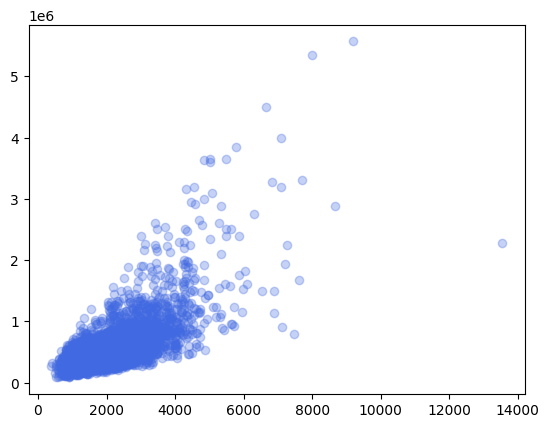

In [14]:
plt.scatter(x_test_real, y_test_real, color='royalblue', alpha=0.3, label='Dados Reais (Teste)')

Plotando a reta prevista pelo modelo

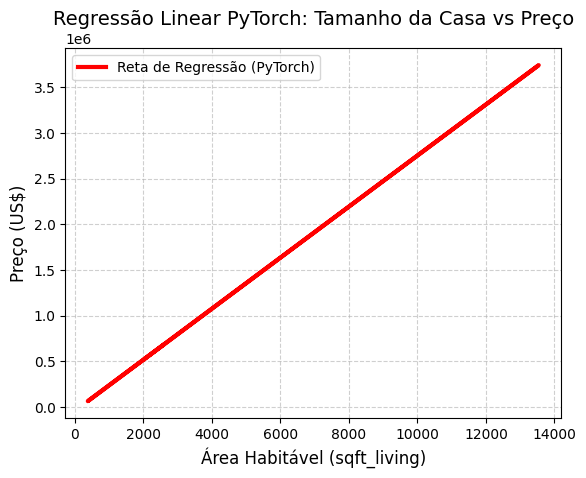

In [15]:
plt.plot(x_test_real, y_pred_real, color='red', linewidth=3, label='Reta de Regressão (PyTorch)')

plt.title('Regressão Linear PyTorch: Tamanho da Casa vs Preço', fontsize=14)
plt.xlabel('Área Habitável (sqft_living)', fontsize=12)
plt.ylabel('Preço (US$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()